In [10]:
from google.colab import files
uploaded=files.upload()

Saving t10k-images.idx3-ubyte to t10k-images (1).idx3-ubyte
Saving t10k-labels.idx1-ubyte to t10k-labels.idx1-ubyte
Saving train-images.idx3-ubyte to train-images.idx3-ubyte
Saving train-labels.idx1-ubyte to train-labels.idx1-ubyte


In [5]:
!pip install idx2numpy

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=1772e59cbbe985c0e2e87fd4cc54626e37c811eee35819204f47abe4cc80c695
  Stored in directory: /root/.cache/pip/wheels/f7/48/00/ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy


In [8]:
import numpy as np
import idx2numpy
import matplotlib.pyplot as plt

In [36]:
X_train_raw = idx2numpy.convert_from_file("train-images.idx3-ubyte")
y_train = idx2numpy.convert_from_file("train-labels.idx1-ubyte")
X_test_raw = idx2numpy.convert_from_file("t10k-images.idx3-ubyte")
y_test = idx2numpy.convert_from_file("t10k-labels.idx1-ubyte")

In [47]:
X_train = X_train_raw.reshape(X_train_raw.shape[0], -1).T / 255.0
X_test = X_test_raw.reshape(X_test_raw.shape[0], -1).T / 255.0


print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")

Training data shape: (784, 60000)
Training labels shape: (60000,)


Initializing weights and biases

In [46]:
def init_params():
    # Random initialization (subtract 0.5 to center weights around 0)
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

Activation functions

In [50]:
def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):

    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)


    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)


    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

def get_predictions(A2):
    return np.argmax(A2, axis=0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

Training the Neural Network

In [53]:
def train_neural_network(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()

    print("\nStarting Training...")
    for i in range(iterations + 1):
        # Forward pass
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)

        # Backward pass
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)

        # Update weights and biases
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        # Log performance every 50 iterations
        if i % 50 == 0:
            predictions = get_predictions(A2)
            accuracy = get_accuracy(predictions, Y)
            print(f"Iteration {i:4d} | Accuracy: {accuracy * 100:.2f}%")

    return W1, b1, W2, b2
W1, b1, W2, b2 = train_neural_network(X_train, y_train, alpha=0.10, iterations=500)


Starting Training...
Iteration    0 | Accuracy: 9.79%
Iteration   50 | Accuracy: 41.69%
Iteration  100 | Accuracy: 61.04%
Iteration  150 | Accuracy: 70.19%
Iteration  200 | Accuracy: 75.21%
Iteration  250 | Accuracy: 78.58%
Iteration  300 | Accuracy: 80.77%
Iteration  350 | Accuracy: 82.33%
Iteration  400 | Accuracy: 83.45%
Iteration  450 | Accuracy: 84.34%
Iteration  500 | Accuracy: 85.05%


Training Accuracy Plot

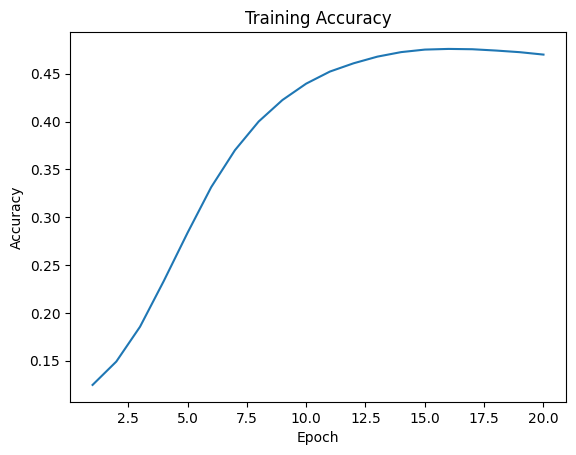

In [52]:
plt.plot(range(1, epochs + 1), train_accuracy)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Testing Model Accuracy

In [54]:
_, _, _, A2_test = forward_prop(W1, b1, W2, b2, X_test)
test_predictions = get_predictions(A2_test)
test_accuracy = get_accuracy(test_predictions, y_test)

print("\n--- Evaluation ---")
print(f"Final Test Dataset Accuracy: {test_accuracy * 100:.2f}%")


--- Evaluation ---
Final Test Dataset Accuracy: 85.43%


**SUMMARY**

- A Neural Network is a machine learning model inspired by the human brain. it learns many small patterns through layers of neurons.

- Weights and Biases: These are parameters. Weights (W) determine how much importance to give to a specific pixel, and Biases(b) adjust how easy it is for a neuron to fire.

- Forward Propagation : The process of passing the input data forward through the network—multiplying by weights, adding biases, and applying activations—to output a final prediction.

- Activation Functions: *ReLU acts like an on/off switch to help the network learn complex, non-linear shapes.

- Softmax turns the final raw scores into clean probabilities (e.g., "There is an 85% chance this image is a 3").

- Backpropagation: The network looks at how wrong its guess was, calculates the error, and travels backward through the layers to figure out exactly which weights and biases caused the mistake.